In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# 1.) Make Dataset

In [3]:
import torch
import numpy as np
from torch.utils.data import Dataset

class MakeDataset(Dataset):
    def __init__(self, x_data, labels=None):

        if isinstance(x_data, torch.Tensor):
            self.X = x_data.float()
        elif isinstance(x_data, np.ndarray):
            self.X = torch.from_numpy(x_data).float()
        else:
            raise TypeError(f"x_data must be a numpy array or torch.Tensor, got {type(x_data)}")

        if labels is not None:
            if isinstance(labels, torch.Tensor):
                y = labels.float()
            elif isinstance(labels, np.ndarray):
                y = torch.from_numpy(labels).float()
            else:
                raise TypeError(f"labels must be a numpy array or torch.Tensor, got {type(labels)}")

            if y.dim() == 1:
                y = y.unsqueeze(1)

            if y.size(0) != self.X.size(0):
                raise ValueError("inputs and labels must have the same length")

            self.y = y
        else:
            self.y = None

    def __len__(self):
        return self.X.size(0)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.y is None:
            return x
        return x, self.y[idx]


In [4]:
data_0 = np.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/test_batch/batch_steps=1e6_0.npz")
data_1 = np.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/test_batch/batch_steps=1e6_1.npz")

inputs_0 = data_0["inputs"]
inputs_1 = data_1["inputs"]

outputs_0 = data_0["currents"]
outputs_1 = data_1["currents"]


inputs = np.concatenate([inputs_0, inputs_1])
outputs = np.concatenate([outputs_0, outputs_1])

print(f"input_shape = {inputs.shape}")
print(f"output_shape = {outputs.shape}")

X_train, X_test, y_train, y_test = train_test_split(inputs, outputs, test_size=0.2, random_state=42, shuffle=True)

train_set = MakeDataset(X_train, y_train)
test_set = MakeDataset(X_test, y_test)

batch_size = 128

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,  num_workers=4)
test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False, num_workers=4)


input_shape = (2000, 8)
output_shape = (2000,)


# 2.) Neural Net

In [5]:
class NeuralNet(nn.Module):
    
    def __init__(
            self,
            in_features: int,
            out_features: int,
            hidden_dim: int,
            num_layers: int
    ):
        super(NeuralNet, self).__init__()

        self.in_features = in_features
        self.out_features = out_features
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.model_layers = self.build_model()
        self.model = nn.Sequential(*self.model_layers)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        
        out = self.model(x)

        return out
    
    def build_model(self):

        layer_list = []

        for l in range(self.num_layers):

            if l == 0:
                layer_list += [nn.Linear(in_features=self.in_features, out_features=self.hidden_dim)]
                layer_list += [nn.ReLU()]

            if l == self.num_layers - 1:
                layer_list += [nn.Linear(in_features=self.hidden_dim, out_features=self.out_features)]

            else:
                layer_list += [nn.Linear(in_features=self.hidden_dim, out_features=self.hidden_dim)]
                layer_list += [nn.ReLU()]
        
        return layer_list

In [6]:
learning_rate = 1e-3
num_epochs = 200

model = NeuralNet(in_features=inputs.shape[1], out_features=1, hidden_dim=64, num_layers=5)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [9]:
for epoch in range(1, num_epochs+1):

    model.train()
    running_loss = 0.0
    for inputs_batch, targets_batch in train_loader:
        inputs_batch  = inputs_batch.to(device, non_blocking=True)
        targets_batch = targets_batch.to(device, non_blocking=True)

        optimizer.zero_grad()
        preds = model(inputs_batch)
        loss  = criterion(preds, targets_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs_batch.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs_batch, targets_batch in test_loader:
            inputs_batch  = inputs_batch.to(device, non_blocking=True)
            targets_batch = targets_batch.to(device, non_blocking=True)

            preds = model(inputs_batch)
            loss  = criterion(preds, targets_batch)
            val_loss += loss.item() * inputs_batch.size(0)

    epoch_val_loss = val_loss / len(test_loader.dataset)

    print(f"Epoch {epoch:2d}/{num_epochs}   "
          f"Train Loss: {epoch_train_loss:.4f}   "
          f"Val Loss: {epoch_val_loss:.4f}")

Epoch  1/200   Train Loss: 0.1061   Val Loss: 0.1132
Epoch  2/200   Train Loss: 0.1033   Val Loss: 0.1097
Epoch  3/200   Train Loss: 0.1006   Val Loss: 0.1059
Epoch  4/200   Train Loss: 0.0973   Val Loss: 0.1012
Epoch  5/200   Train Loss: 0.0929   Val Loss: 0.0952
Epoch  6/200   Train Loss: 0.0870   Val Loss: 0.0874
Epoch  7/200   Train Loss: 0.0793   Val Loss: 0.0782
Epoch  8/200   Train Loss: 0.0702   Val Loss: 0.0673
Epoch  9/200   Train Loss: 0.0597   Val Loss: 0.0554
Epoch 10/200   Train Loss: 0.0485   Val Loss: 0.0431
Epoch 11/200   Train Loss: 0.0375   Val Loss: 0.0320
Epoch 12/200   Train Loss: 0.0281   Val Loss: 0.0236
Epoch 13/200   Train Loss: 0.0212   Val Loss: 0.0184
Epoch 14/200   Train Loss: 0.0170   Val Loss: 0.0152
Epoch 15/200   Train Loss: 0.0141   Val Loss: 0.0131
Epoch 16/200   Train Loss: 0.0121   Val Loss: 0.0115
Epoch 17/200   Train Loss: 0.0105   Val Loss: 0.0102
Epoch 18/200   Train Loss: 0.0094   Val Loss: 0.0093
Epoch 19/200   Train Loss: 0.0085   Val Loss: 

In [10]:
torch.save(model.state_dict(), "best_model.pth")

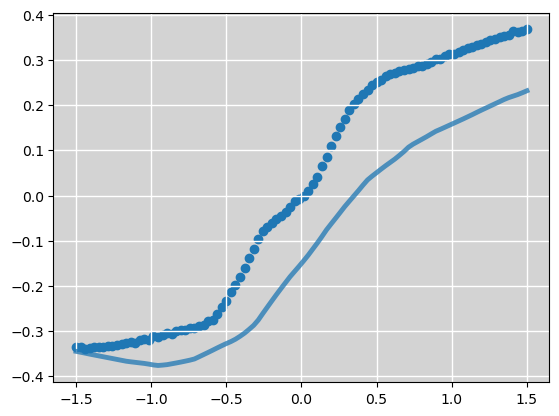

In [16]:
state_dict = torch.load(f="best_model.pth")
model.load_state_dict(state_dict=state_dict)
model.eval()

sim_curve = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/test_folder/test_file_7000.npz")
vs_ = torch.linspace(-1.5, 1.5, 50)

n = 100
vs = torch.linspace(-1.5, 1.5, n)

x = torch.tensor([0.0, 0.0, 1.5, -0.3, 1.0, -1.1, -0.8, -0.2])
control_volts = x.unsqueeze(0).repeat(n, 1)
control_volts[:, 1] = vs

out = model(control_volts)

plot_kwargs = {
    "lw": 3.5,
    "alpha": 0.75
}
plt.scatter(vs, sim_curve["current"])
plt.plot(vs, out.detach(), **plot_kwargs, zorder=3)
ax = plt.gca()
ax.grid(True)
ax.set_facecolor("lightgrey")
ax.xaxis.grid(color="w", lw=1.)
ax.yaxis.grid(color="w", lw=1.)